In [29]:
import numpy as np
def exponential_moving_average(data, alpha=0.1):
    ema = []
    for i, v in enumerate(data):
        if i == 0:
            ema.append(v)
        else:
            ema.append(alpha * v + (1 - alpha) * ema[-1])
    return ema


def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [1374.0, 1591.0, 1599.0, 1551.0, 1517.0, 1765.0, 1662.0, 1491.0, 1523

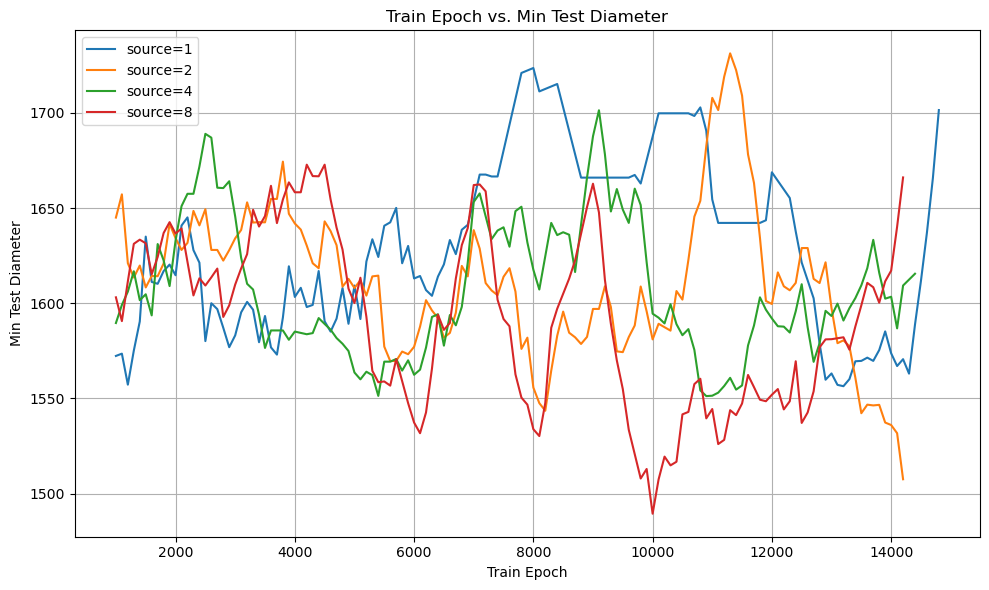

In [37]:
import re
import os
import matplotlib.pyplot as plt

def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    min_diameter_list = [float(m[1]) for m in matches]

    return epoch_list, min_diameter_list


    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # best_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))
for label, (epochs, diameters) in log_data.items():
    # plt.plot(epochs, diameters, label=label)
    smoothed_loss = moving_average(diameters, window_size=10)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [77924.4141, 57243.0391, 76600.7266, 78620.9297, 148461.7812, 3014785

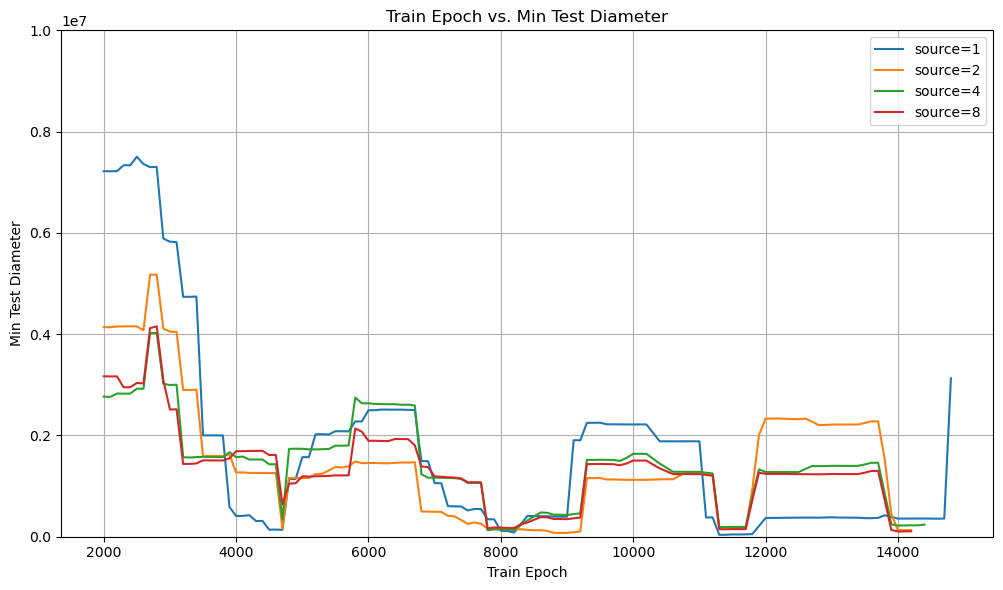

In [35]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np


def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # min_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, min_diameter_list
    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?loss\s*=\s*([\d\.eE\+\-]+)",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    loss = [float(m[1]) for m in matches]

    return epoch_list, loss

    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # best_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))

for label, (epochs, diameters) in log_data.items():
    # ema_loss = exponential_moving_average(diameters, alpha=0.1)
    smoothed_loss = moving_average(diameters, window_size=20)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim([0, 1e7])
plt.show()

([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374

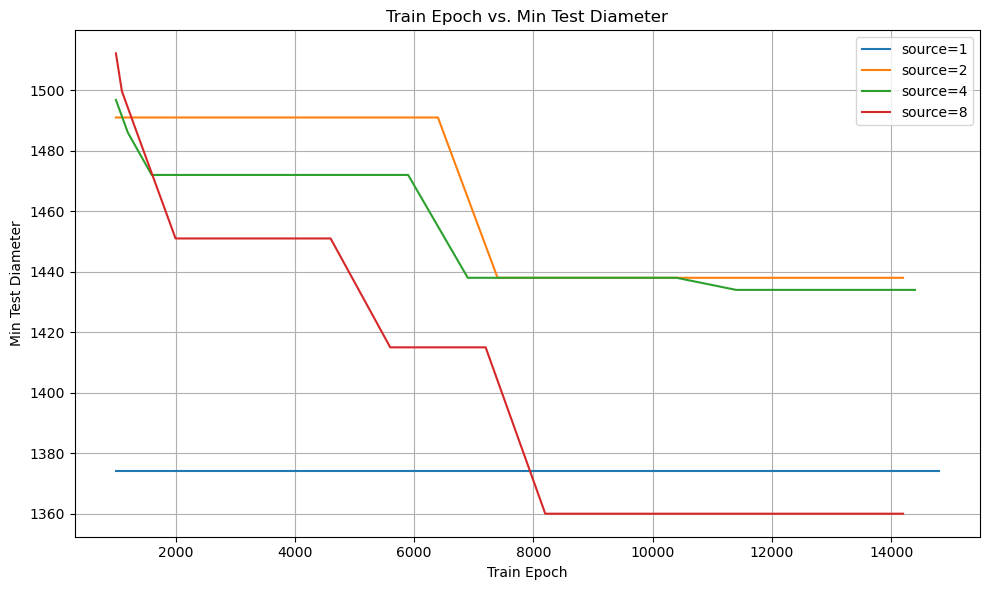

In [36]:
import re
import os
import matplotlib.pyplot as plt

def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # min_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, min_diameter_list


    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    best_diameter_list = [float(m[1]) for m in matches]

    return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))
for label, (epochs, diameters) in log_data.items():
    # plt.plot(epochs, diameters, label=label)
    smoothed_loss = moving_average(diameters, window_size=10)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# num_source=1
diameter mean=1235.0999755859375, std=89.98944091796875, min=1117.0, max=1412.0
Max Test Diameter [1412.0]
Min Test Diameter [1117.0]

# num_source=2
diameter mean=1346.9000244140625, std=89.84981536865234, min=1233.0, max=1475.0
Max Test Diameter [1475.0]
Min Test Diameter [1233.0]

# num_source=4
diameter mean=1372.4000244140625, std=125.71590423583984, min=1213.0, max=1683.0
Max Test Diameter [1683.0]
Min Test Diameter [1213.0]

# num_source=8
diameter mean=1429.800048828125, std=389.6253967285156, min=1194.0, max=2518.0
Max Test Diameter [2518.0]
Min Test Diameter [1194.0]

Processing results for N=400 nodes...
Output will be saved in: ../sc_test/400_histo_seed=1234_FABRIC

ANALYZING METHOD: chord_shortest_ring


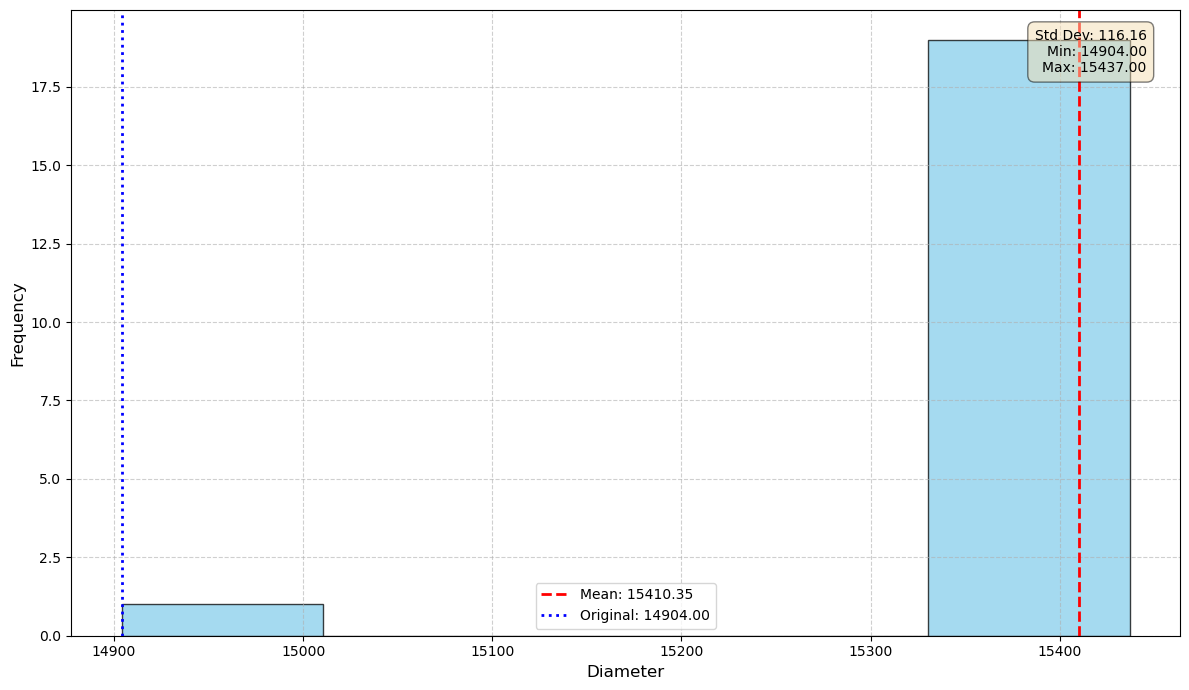

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_chord_shortest_ring.pkl

Statistics for 'chord_shortest_ring':
Original diameter: 14904.00
Mean diameter over 20 runs: 15410.35
Standard Deviation: 116.16
Min diameter: 14904.00
Max diameter: 15437.00

ANALYZING METHOD: chord_random_ring


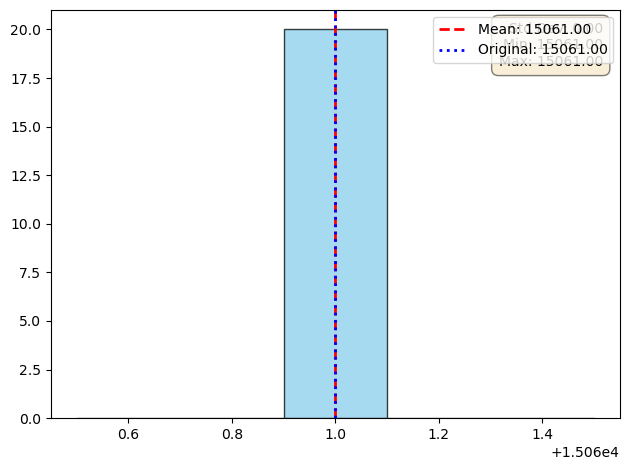

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_chord_random_ring.pkl

Statistics for 'chord_random_ring':
Original diameter: 15061.00
Mean diameter over 20 runs: 15061.00
Standard Deviation: 0.00
Min diameter: 15061.00
Max diameter: 15061.00

ANALYZING METHOD: nearest_neighbour_shortest_ring


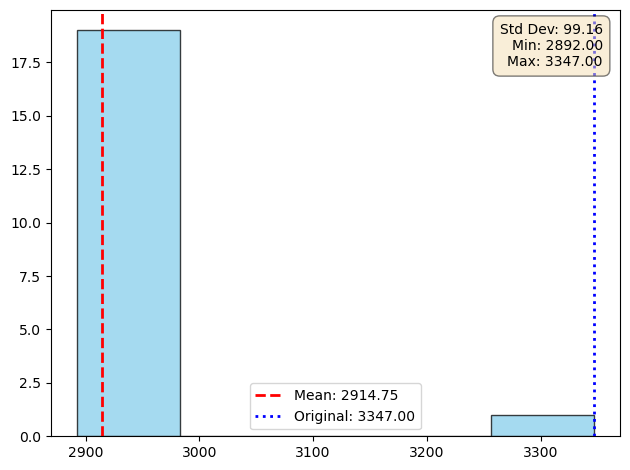

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_nearest_neighbour_shortest_ring.pkl

Statistics for 'nearest_neighbour_shortest_ring':
Original diameter: 3347.00
Mean diameter over 20 runs: 2914.75
Standard Deviation: 99.16
Min diameter: 2892.00
Max diameter: 3347.00

ANALYZING METHOD: nearest_neighbour_random_ring


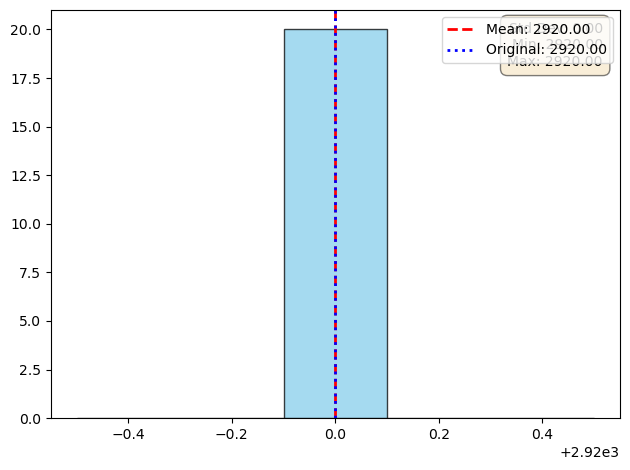

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_nearest_neighbour_random_ring.pkl

Statistics for 'nearest_neighbour_random_ring':
Original diameter: 2920.00
Mean diameter over 20 runs: 2920.00
Standard Deviation: 0.00
Min diameter: 2920.00
Max diameter: 2920.00

ANALYZING METHOD: K_ring_shortest_ring


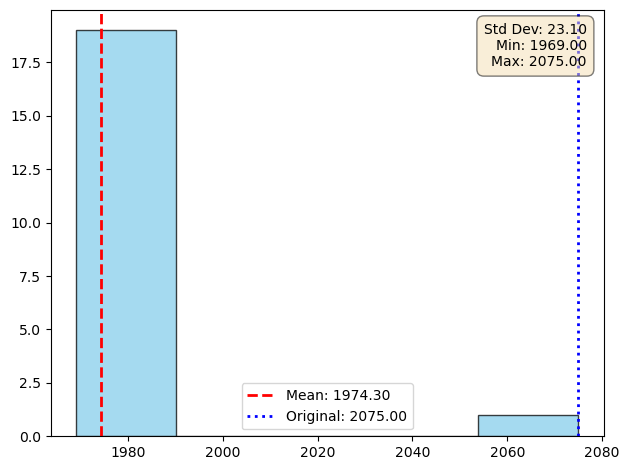

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_K_ring_shortest_ring.pkl

Statistics for 'K_ring_shortest_ring':
Original diameter: 2075.00
Mean diameter over 20 runs: 1974.30
Standard Deviation: 23.10
Min diameter: 1969.00
Max diameter: 2075.00

ANALYZING METHOD: K_ring_random_ring


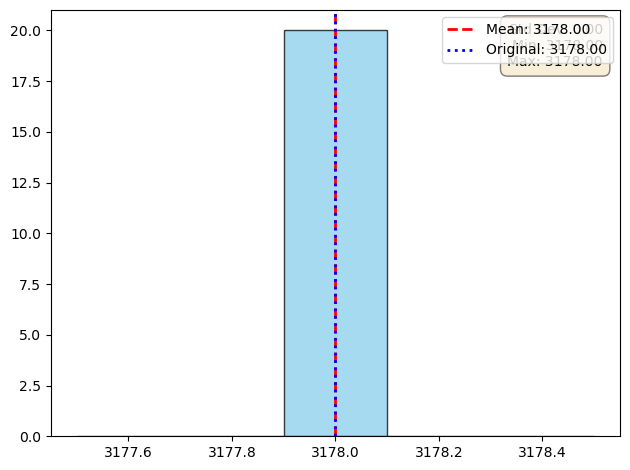

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_K_ring_random_ring.pkl

Statistics for 'K_ring_random_ring':
Original diameter: 3178.00
Mean diameter over 20 runs: 3178.00
Standard Deviation: 0.00
Min diameter: 3178.00
Max diameter: 3178.00

ANALYZING METHOD: K_ring_greedy


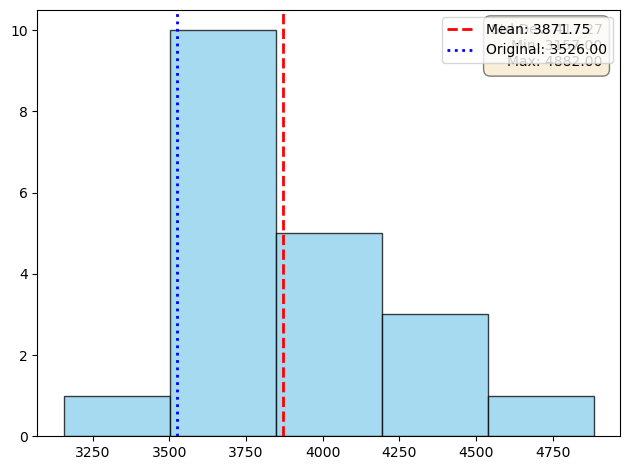

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_K_ring_greedy.pkl

Statistics for 'K_ring_greedy':
Original diameter: 3526.00
Mean diameter over 20 runs: 3871.75
Standard Deviation: 417.27
Min diameter: 3157.00
Max diameter: 4882.00

ANALYZING METHOD: K_ring_epsilon_greedy


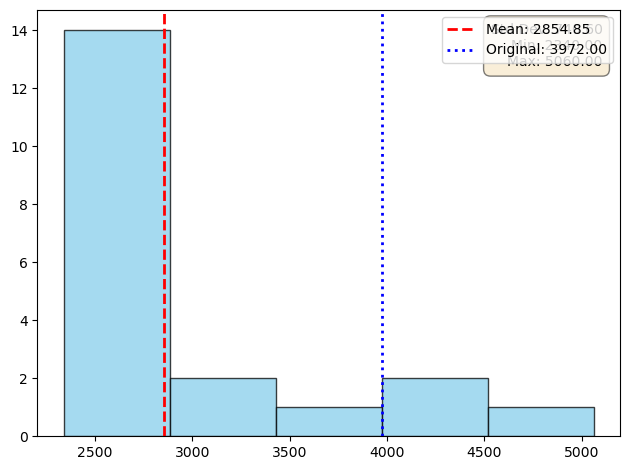

Result data saved to: ../sc_test/400_histo_seed=1234_FABRIC/results_K_ring_epsilon_greedy.pkl

Statistics for 'K_ring_epsilon_greedy':
Original diameter: 3972.00
Mean diameter over 20 runs: 2854.85
Standard Deviation: 740.60
Min diameter: 2340.00
Max diameter: 5060.00

ALL ANALYSES COMPLETE.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
import argparse

# --- Data Provided by User ---
# I've parsed your string into a Python dictionary format.
results_data = {
    400: {'chord_shortest_ring': [14904.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0, 15437.0], 'chord_random_ring': [15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0, 15061.0], 'nearest_neighbour_shortest_ring': [3347.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0, 2892.0], 'nearest_neighbour_random_ring': [2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0, 2920.0], 'K_ring_shortest_ring': [2075.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0, 1969.0], 'K_ring_random_ring': [3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0, 3178.0], 'K_ring_greedy': [3526.0, 3157.0, 3548.0, 3846.0, 3589.0, 3548.0, 4454.0, 3863.0, 3774.0, 4454.0, 3548.0, 4353.0, 3863.0, 4183.0, 4106.0, 4882.0, 3548.0, 3548.0, 4097.0, 3548.0], 'K_ring_epsilon_greedy': [3972.0, 3085.0, 2343.0, 2396.0, 2502.0, 4262.0, 2404.0, 2919.0, 2472.0, 2362.0, 2476.0, 5060.0, 2635.0, 2340.0, 2474.0, 2410.0, 2597.0, 2547.0, 2345.0, 3496.0]}
}

# --- Simulation Parameters (Placeholders based on your code) ---
# In a real script, these would be passed via command line arguments.
parser = argparse.ArgumentParser()
parser.add_argument('--N', type=int, default=400, help='Number of nodes')
parser.add_argument('--K', type=int, default=3, help='Degree constraint (k-ring)')
args = parser.parse_args([]) # Use default values

seed = 1234 # Example seed

# --- Main Script Logic ---

# Get the data for the specified number of nodes
node_count = args.N
if node_count not in results_data:
    print(f"Error: No data found for N={node_count}")
else:
    method_results = results_data[node_count]
    print(f"Processing results for N={node_count} nodes...")

    # Create a master directory for the output
    output_dir_base = f'../sc_test/{args.N}_histo_seed={seed}_FABRIC'
    os.makedirs(output_dir_base, exist_ok=True)
    print(f"Output will be saved in: {output_dir_base}")

    # Loop through each method and generate plots and statistics
    for method_name, diameter_list in method_results.items():
        print("\n" + "="*80)
        print(f"ANALYZING METHOD: {method_name}")
        print("="*80)

        if diameter_list:
            # The first value is often the baseline before noise/failure
            original_diameter = diameter_list[0]

            # --- Plotting ---
            plt.figure(figsize=(12, 7))
            plt.hist(diameter_list, bins=5, edgecolor='black', alpha=0.75, color='skyblue')
            
            # --- Titles and Labels ---
            title = (f'Diameter Distribution for: {method_name}\n'
                     f'N={args.N}, K={args.K} (Original Diameter: {original_diameter:.2f})')
            plt.title(title, fontsize=16)
            plt.xlabel('Diameter', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)

            # --- Statistical Annotations ---
            mean_diameter = np.mean(diameter_list)
            std_diameter = np.std(diameter_list)
            
            plt.axvline(mean_diameter, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_diameter:.2f}')
            plt.axvline(original_diameter, color='blue', linestyle=':', linewidth=2, label=f'Original: {original_diameter:.2f}')
            
            # Add a text box for more stats
            stats_text = (f'Std Dev: {std_diameter:.2f}\n'
                          f'Min: {min(diameter_list):.2f}\n'
                          f'Max: {max(diameter_list):.2f}')
            plt.text(0.97, 0.97, stats_text, transform=plt.gca().transAxes, fontsize=10,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
            
            plt.legend()
            plt.tight_layout()

            # --- Saving Figure ---
            # Use the method name in the filename for clarity
            figure_path = os.path.join(output_dir_base, f'hist_{method_name}.png')
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            print(f"Histogram saved to: {figure_path}")
            plt.show() # Display the plot

            # --- Saving Data ---
            noise_results = {
                'method_name': method_name,
                'original_diameter': original_diameter,
                'diameter_list': diameter_list,
                'mean_diameter': mean_diameter,
                'std_diameter': std_diameter,
                'min_diameter': min(diameter_list),
                'max_diameter': max(diameter_list)
            }
            
            # Use the method name in the pickle filename
            data_path = os.path.join(output_dir_base, f'results_{method_name}.pkl')
            with open(data_path, 'wb') as f:
                pkl.dump(noise_results, f)
            print(f"Result data saved to: {data_path}")

            # --- Printing Statistics to Console ---
            print(f"\nStatistics for '{method_name}':")
            print(f"Original diameter: {original_diameter:.2f}")
            print(f"Mean diameter over {len(diameter_list)} runs: {mean_diameter:.2f}")
            print(f"Standard Deviation: {std_diameter:.2f}")
            print(f"Min diameter: {min(diameter_list):.2f}")
            print(f"Max diameter: {max(diameter_list):.2f}")
        else:
            print(f"No diameter data found for method: {method_name}")

    print("\n" + "="*80)
    print("ALL ANALYSES COMPLETE.")
    print("="*80)

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)